 # Customer Segmentation Using K-Means Clustering

## Introduction: The Problem We Are Solving

In today’s data-driven world, businesses no longer treat all customers the same. Every customer behaves differently — some spend a lot, some spend little, some are loyal, and others need incentives to engage.

The major challenge businesses face is:

> **“How can we understand different types of customers and target them effectively to increase revenue?”**

If a company sends the same marketing message to all customers:

* High-value customers may feel undervalued
* Low-value customers may not respond
* Marketing budget is wasted

This leads to:

* Poor customer engagement
* Low conversion rates
* Reduced profitability

##  Objective of This Project

The goal of this project is to:

* Identify **distinct groups of customers** based on their behavior
* Understand **spending patterns and income levels**
* Help businesses make **data-driven marketing decisions**

We will achieve this using **unsupervised machine learning**, specifically:

> **K-Means Clustering**


## What is Clustering?

Clustering is a machine learning technique used to:

> Group similar data points together without predefined labels.

Unlike supervised learning:

* There is **no target variable**
* The model **discovers hidden patterns on its own**


## Algorithm Used: K-Means Clustering

K-Means is one of the most popular clustering algorithms.

###  How It Works (Step-by-Step)

1. Choose the number of clusters (**K**)
2. Randomly initialize **K centroids** (center points)
3. Assign each data point to the **nearest centroid**
4. Recalculate the centroids based on assigned points
5. Repeat steps 3–4 until clusters stabilize


##  Why K-Means?

We use K-Means because:

* It is **simple and easy to understand**
* It is **fast and efficient**
* It works well for **numerical data**
* It produces **clear and interpretable clusters**


##  Important Considerations

* The value of **K must be chosen carefully**
* K-Means works best when:

  * Clusters are **well separated**
  * Data is **numerical**
* It assumes clusters are roughly **circular in shape**


##  Other Clustering Algorithms (For Further Study)

While we are using K-Means, there are other clustering techniques:

* **Hierarchical Clustering**

  * Builds a tree-like structure (dendrogram)
  * No need to choose K initially

* **DBSCAN (Density-Based Clustering)**

  * Detects clusters based on density
  * Can identify noise/outliers

* **Gaussian Mixture Models (GMM)**

  * Uses probability distributions
  * More flexible than K-Means


##  Real-World Application

In this project, we apply clustering to:

> **Customer Segmentation**

We group customers based on:

* Annual Income
* Spending Score

This allows businesses to:

* Identify **high-value customers**
* Target **specific groups with tailored strategies**
* Improve **marketing efficiency and revenue**


##  Expected Outcome

By the end of this project, you will be able to:

* Apply K-Means clustering to real data
* Choose the optimal number of clusters
* Interpret clusters into meaningful business insights
* Translate data into **actionable decisions**




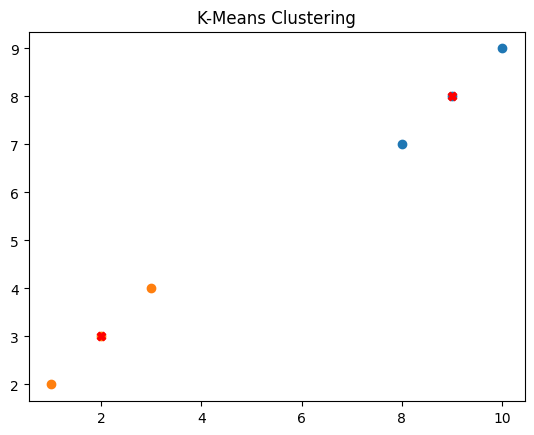

In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Sample data
X = [[1,2], [2,3], [3,4], [8,7], [9,8], [10,9]]

# Train model
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

# Predictions
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Plot
for i, point in enumerate(X):
    plt.scatter(point[0], point[1], c=f"C{labels[i]}")

plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X')
plt.title("K-Means Clustering")
plt.show()

In [ ]:
X = [[1,2], [2,3], [3,4], [8,7], [9,8], [10,9]]

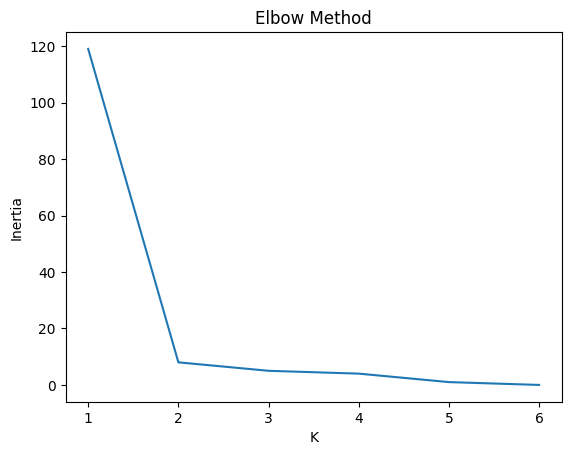

In [4]:
inertia = []
K = range(1, 7)
for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

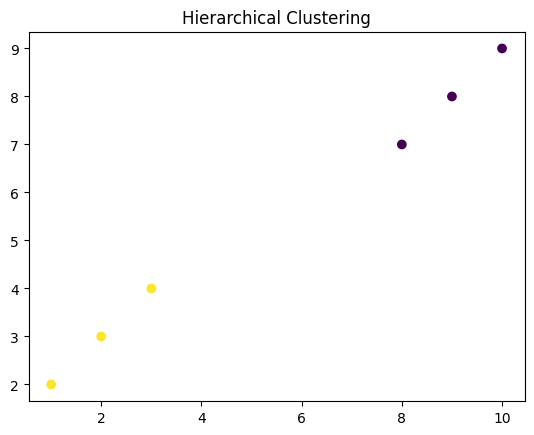

In [3]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=2)
labels = model.fit_predict(X)

plt.scatter([p[0] for p in X], [p[1] for p in X], c=labels)
plt.title("Hierarchical Clustering")
plt.show()

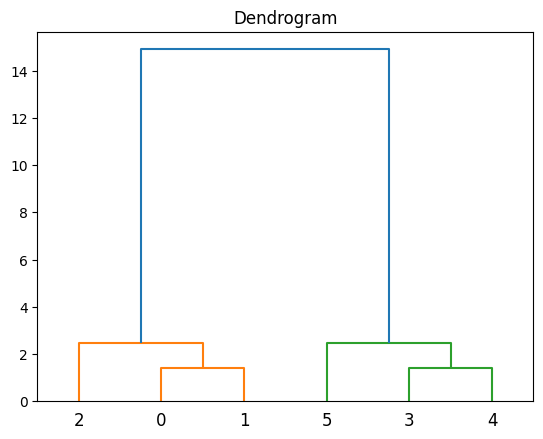

In [5]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, method='ward')

dendrogram(linked)
plt.title("Dendrogram")
plt.show()

## IMPORTS LIBRARIES

* pandas → “We use this to read and manipulate data."
* matplotlib → “We use this to SEE patterns."
* KMeans → “This is the algorithm doing the clustering."
* silhouette_score → “This tells us if our clustering is good or bad."
* linkage, dendrogram → “Used for hierarchical clustering (tree structure)”

In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 
from scipy.cluster.hierarchy import dendrogram, linkage  

## LOAD DATASET

In [5]:

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Feature Selection (CRITICAL)

Explain:

We choose only useful features
Clustering depends on distance
So we pick numerical, meaningful variables

“Bad features = bad clusters”.

In [7]:
x = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [12]:
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


### Visualization

Before modeling, always ask:

“What does the data already show us?”

This builds intuition.

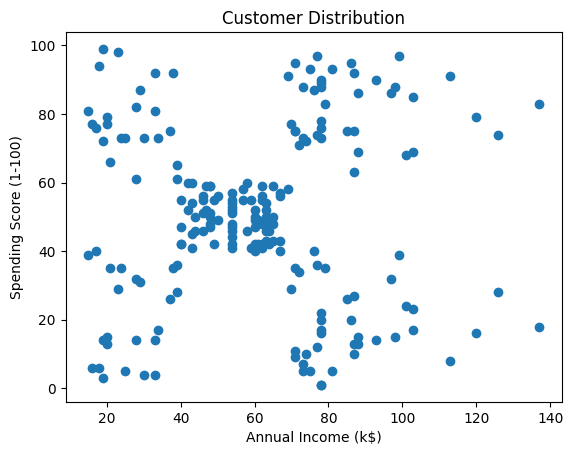

In [8]:
# VISUALIZE THE DATA
plt.scatter(x.iloc[:,0], x.iloc[:,1])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")
plt.show()


## Elbow Method

Explain:

Inertia = how tight clusters are
Lower = better, but…
We don’t want too many clusters

The "elbow" is the balance point


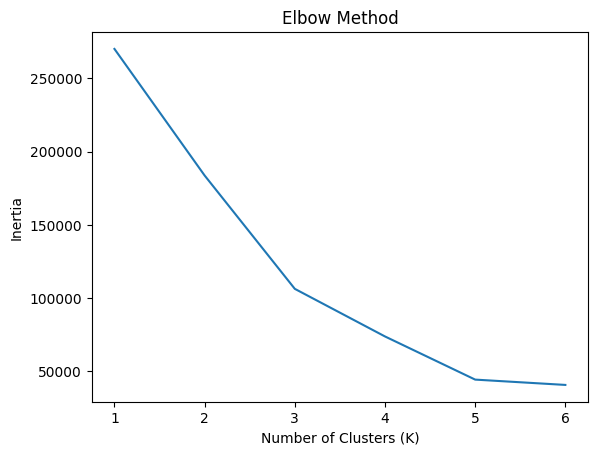

In [9]:
# ELBOW METHOD (CHOOSING K)

inertia = []
K = range(1, 7)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## K-Means Model

Explain internally what happens:

Pick K points (centroids)
Assign points to nearest centroid
Recalculate centroids
Repeat

Key idea:

“K-Means is trying to minimize distance”

### Visualization of Clusters

This is the most important moment


“What kind of customers are in each group?”

“Who should the business target?”

Turn ML → Business thinking

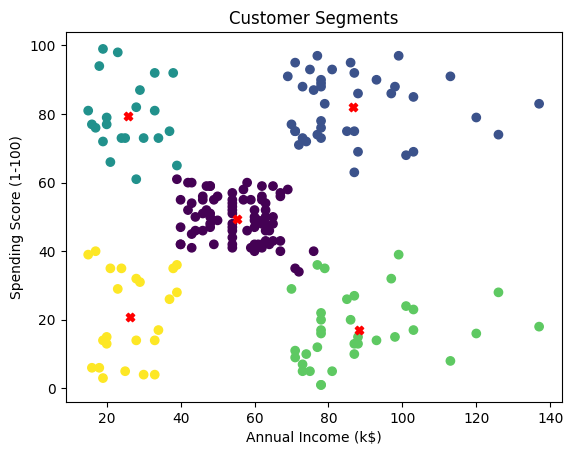

In [13]:
# APPLY K-MEANS
# Choose K based on elbow (commonly 5 here)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(x)


# VISUALIZE CLUSTERS


plt.scatter(x.iloc[:,0], x.iloc[:,1], c=y_kmeans)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.show()


## Silhouette Score

Explain:

* Range: -1 to 1
* Close to 1 → good clusters
* Close to 0 → overlapping clusters
* Negative → bad clustering

In [17]:
centroids = kmeans.cluster_centers_

for i, center in enumerate(centroids):
    print(f"Cluster {i}: Income={center[0]}, Spending={center[1]}")

Cluster 0: Income=55.29629629629632, Spending=49.51851851851852
Cluster 1: Income=86.53846153846155, Spending=82.12820512820511
Cluster 2: Income=25.727272727272755, Spending=79.36363636363636
Cluster 3: Income=88.20000000000002, Spending=17.1142857142857
Cluster 4: Income=26.304347826086982, Spending=20.913043478260867


In [12]:

# EVALUATE MODEL (SILHOUETTE SCORE)


score = silhouette_score(x, y_kmeans)
print("Silhouette Score:", score)


Silhouette Score: 0.553931997444648


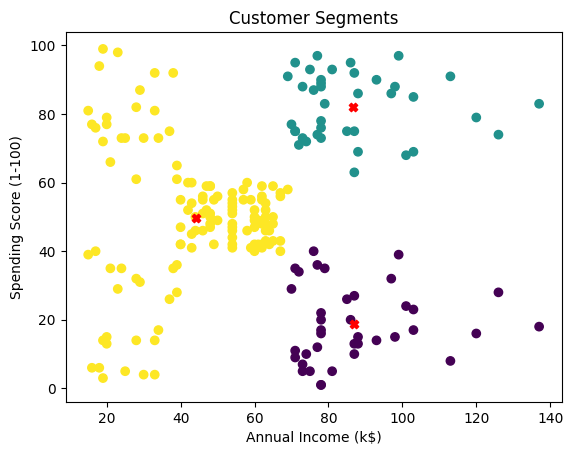

In [13]:
# APPLY K-MEANS
# Choose K based on elbow (commonly 5 here)
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(x)


# VISUALIZE CLUSTERS


plt.scatter(x.iloc[:,0], x.iloc[:,1], c=y_kmeans)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments")
plt.show()


In [14]:
score = silhouette_score(x, y_kmeans)
print("Silhouette Score:", score)


Silhouette Score: 0.46761358158775435


### Hierarchical Clustering

Explain differently:

“Instead of guessing K, we build a tree and decide later”

Dendrogram = decision tool

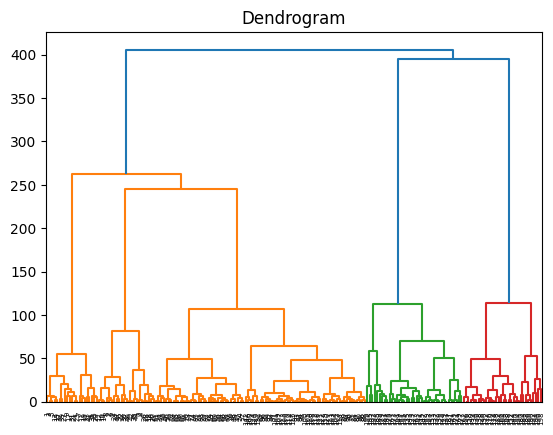

In [30]:

# HIERARCHICAL CLUSTERING


linked = linkage(x, method='ward')

dendrogram(linked)
plt.title("Dendrogram")
plt.show()


In [11]:
cluster_map = {
    0: "C - Average",
    1: "A - Premium",
    2: "E - Impulsive",
    3: "B - Careful Spenders",
    4: "D - Low Value"
}

In [19]:
df['Cluster'] = y_kmeans
df['Segment'] = df['Cluster'].map(cluster_map)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,D - Low Value
1,2,Male,21,15,81,2,E - Impulsive
2,3,Female,20,16,6,4,D - Low Value
3,4,Female,23,16,77,2,E - Impulsive
4,5,Female,31,17,40,4,D - Low Value


In [11]:
df["Segment"].value_counts()

Segment
C - Average             81
A - Premium             39
B - Careful Spenders    35
D - Low Value           23
E - Impulsive           22
Name: count, dtype: int64

In [12]:
summary = df.groupby('Segment').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Customer Count'})

summary

,Annual Income (k$),Spending Score (1-100),Customer Count
Segment,,,
A - Premium,86.538462,82.128205,39
B - Careful Spenders,88.200000,17.114286,35
C - Average,55.296296,49.518519,81
D - Low Value,26.304348,20.913043,23
E - Impulsive,25.727273,79.363636,22


In [12]:
high_value = df.sort_values(by='Spending Score (1-100)', ascending=False)
high_value.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
11,12,Female,35,19,99
19,20,Female,35,23,98
145,146,Male,28,77,97
185,186,Male,30,99,97
167,168,Female,33,86,95
127,128,Male,40,71,95
7,8,Female,23,18,94
163,164,Female,31,81,93
141,142,Male,32,75,93
173,174,Male,36,87,92


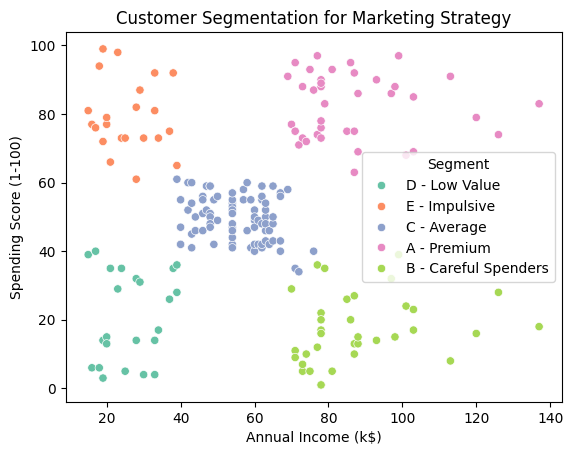

In [13]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Segment',
    palette='Set2'
)

plt.title("Customer Segmentation for Marketing Strategy")
plt.show()


##  Key Question to Think About

> Is it possible to use the result as marketing manager to improve the sales of your Company?

> “If you were the marketing manager, how would you use these customer groups to increase sales?”
>
> https://www.youtube.com/watch?v=qBigTkBLU6g&list=PLblh5JKOoLUK0FLuzwntyYI10UQFUhsY9